In [ ]:
!pip install xgboost opencv-python kagglehub tensorflow -q

In [ ]:
import numpy as np
import os
import cv2
import matplotlib.pyplot as plt
import pandas as pd
import kagglehub
import tensorflow as tf

from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    accuracy_score,
    f1_score,
    confusion_matrix,
    classification_report,
    ConfusionMatrixDisplay
)

from xgboost import XGBClassifier
from tensorflow.keras.applications import VGG16
from tensorflow.keras.applications.vgg16 import preprocess_input
from tensorflow.keras.models import Model

np.random.seed(42)
tf.random.set_seed(42)
os.makedirs("outputs", exist_ok=True)

In [ ]:
#path
path = kagglehub.dataset_download(
    "paultimothymooney/chest-xray-pneumonia"
)
print("Dataset Path :", path)

Using Colab cache for faster access to the 'chest-xray-pneumonia' dataset.
Dataset Path : /kaggle/input/chest-xray-pneumonia


In [ ]:
#classes
classes = {
    'NORMAL': 0,
    'PNEUMONIA': 1
}

dec = {
    0: 'Normal',
    1: 'Pneumonia'
}

IMG_SIZE = 224

In [ ]:
#load
train_path = os.path.join(
    path,
    "chest_xray",
    "train"
)

test_path = os.path.join(
    path,
    "chest_xray",
    "test"
)
def load_rgb_images(folder_path):
    X = []
    Y = []
    for cls, label in classes.items():

        class_path = os.path.join(
            folder_path,
            cls
        )
        count = 0
        for filename in os.listdir(class_path):

            img_path = os.path.join(
                class_path,
                filename
            )

            img = cv2.imread(img_path)

            if img is not None:

                img = cv2.cvtColor(
                    img,
                    cv2.COLOR_BGR2RGB
                )

                img = cv2.resize(
                    img,
                    (IMG_SIZE, IMG_SIZE)
                )

                X.append(img)
                Y.append(label)
                count += 1

        print(f"{cls} : {count} images loaded")

    return np.array(X, dtype=np.float32), np.array(Y)

print("Loading Training Images...\n")

X_train_raw, Y_train = load_rgb_images(
    train_path
)

print("\nLoading Testing Images...\n")

X_test_raw, Y_test = load_rgb_images(
    test_path
)

print("\nTraining Shape :", X_train_raw.shape)
print("Testing Shape  :", X_test_raw.shape)
print("\nNORMAL     :", np.sum(Y_train==0))
print("PNEUMONIA :", np.sum(Y_train==1))

Loading Training Images...

NORMAL : 1341 images loaded
PNEUMONIA : 3875 images loaded

Loading Testing Images...

NORMAL : 234 images loaded
PNEUMONIA : 390 images loaded

Training Shape : (5216, 224, 224, 3)
Testing Shape  : (624, 224, 224, 3)

NORMAL     : 1341
PNEUMONIA : 3875


In [ ]:
#feature extractor build

print("Building VGG16 Feature Extractor...\n")

base_vgg = VGG16(
    weights='imagenet',
    include_top=False,
    input_shape=(224,224,3)
)

base_vgg.trainable = False

gap_output = tf.keras.layers.GlobalAveragePooling2D()(
    base_vgg.output
)

extractor = Model(
    inputs=base_vgg.input,
    outputs=gap_output
)

extractor.summary()

Building VGG16 Feature Extractor...

58889256/58889256 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)        │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block1_conv1 (Conv2D)           │ (None, 224, 224, 64)   │         1,792 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block1_conv2 (Conv2D)           │ (None, 224, 224, 64)   │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block1_pool (MaxPooling2D)      │ (None, 112, 112, 64)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block2_conv1 (Conv2D)           │ (None, 112, 112, 128)  │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block2_conv2 (Conv2D)           │ (None, 112, 112, 128)  │       147,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block2_pool (MaxPooling2D)      │ (None, 56, 56, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_conv1 (Conv2D)           │ (None, 56, 56, 256)    │       295,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_conv2 (Conv2D)           │ (None, 56, 56, 256)    │       590,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_conv3 (Conv2D)           │ (None, 56, 56, 256)    │       590,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_pool (MaxPooling2D)      │ (None, 28, 28, 256)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_conv1 (Conv2D)           │ (None, 28, 28, 512)    │     1,180,160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_conv2 (Conv2D)           │ (None, 28, 28, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_conv3 (Conv2D)           │ (None, 28, 28, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_pool (MaxPooling2D)      │ (None, 14, 14, 512)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_conv1 (Conv2D)           │ (None, 14, 14, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_conv2 (Conv2D)           │ (None, 14, 14, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_conv3 (Conv2D)           │ (None, 14, 14, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_pool (MaxPooling2D)      │ (None, 7, 7, 512)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 512)            │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 14,714,688 (56.13 MB)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 14,714,688 (56.13 MB)

In [ ]:
#cgg16 feature extract
BATCH = 32

# TRAIN FEATURES
X_train_preprocessed = preprocess_input(
    X_train_raw.copy()
)
train_features = []

print("\nExtracting Training Features...\n")

for i in range(0, len(X_train_preprocessed), BATCH):

    batch_features = extractor.predict(
        X_train_preprocessed[i:i+BATCH],
        verbose=0
    )

    train_features.append(batch_features)
X_train_feats = np.vstack(train_features)

# TEST FEATURES
X_test_preprocessed = preprocess_input(
    X_test_raw.copy()
)

test_features = []

print("\nExtracting Testing Features...\n")

for i in range(0, len(X_test_preprocessed), BATCH):

    batch_features = extractor.predict(
        X_test_preprocessed[i:i+BATCH],
        verbose=0
    )

    test_features.append(batch_features)

X_test_feats = np.vstack(test_features)

print("\nTrain Feature Shape :", X_train_feats.shape)
print("Test Feature Shape  :", X_test_feats.shape)


Extracting Training Features...


Extracting Testing Features...


Train Feature Shape : (5216, 512)
Test Feature Shape  : (624, 512)


In [ ]:
#training percentages
train_sizes = [0.2, 0.4, 0.6, 0.8]


TRAINING DATA USED : 20%
TESTING DATA USED  : 100% Official Test Set
Training Samples : 1043
Testing Samples  : 624

Training VGG16 + XGBoost Model...
Training Completed
Training Accuracy : 0.9760306807286673
Testing Accuracy  : 0.7900641025641025
F1 Score          : 0.7732102484481655
Sensitivity       : 0.9615384615384616
Specificity       : 0.5042735042735043

Classification Report:

              precision    recall  f1-score   support

      Normal       0.89      0.50      0.64       234
   Pneumonia       0.76      0.96      0.85       390

    accuracy                           0.79       624
   macro avg       0.83      0.73      0.75       624
weighted avg       0.81      0.79      0.77       624



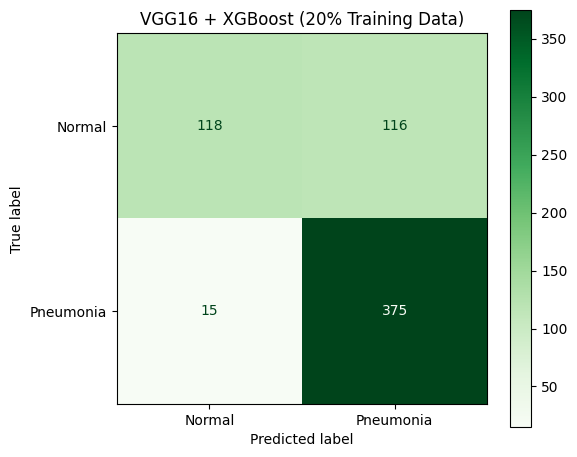


TRAINING DATA USED : 40%
TESTING DATA USED  : 100% Official Test Set
Training Samples : 2086
Testing Samples  : 624

Training VGG16 + XGBoost Model...
Training Completed
Training Accuracy : 0.9736337488015341
Testing Accuracy  : 0.8173076923076923
F1 Score          : 0.8073426573426574
Sensitivity       : 0.9538461538461539
Specificity       : 0.5897435897435898

Classification Report:

              precision    recall  f1-score   support

      Normal       0.88      0.59      0.71       234
   Pneumonia       0.79      0.95      0.87       390

    accuracy                           0.82       624
   macro avg       0.84      0.77      0.79       624
weighted avg       0.83      0.82      0.81       624



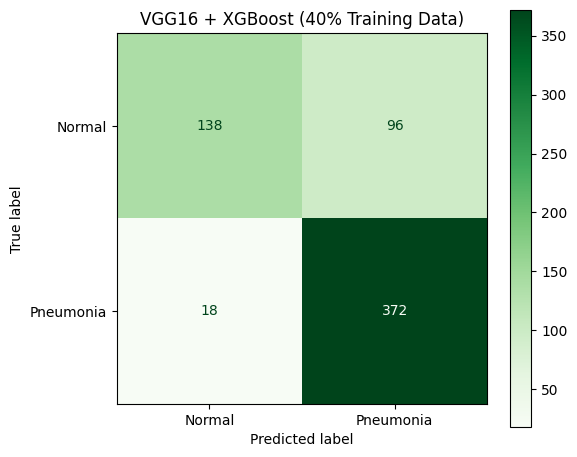


TRAINING DATA USED : 60%
TESTING DATA USED  : 100% Official Test Set
Training Samples : 3129
Testing Samples  : 624

Training VGG16 + XGBoost Model...
Training Completed
Training Accuracy : 0.9693192713326941
Testing Accuracy  : 0.8092948717948718
F1 Score          : 0.7986995400283105
Sensitivity       : 0.9487179487179487
Specificity       : 0.5769230769230769

Classification Report:

              precision    recall  f1-score   support

      Normal       0.87      0.58      0.69       234
   Pneumonia       0.79      0.95      0.86       390

    accuracy                           0.81       624
   macro avg       0.83      0.76      0.78       624
weighted avg       0.82      0.81      0.80       624



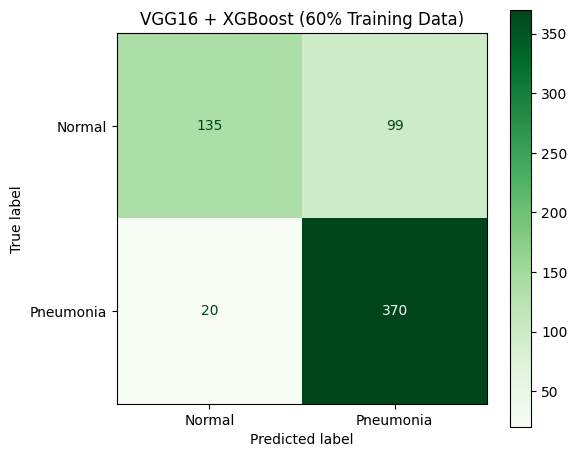


TRAINING DATA USED : 80%
TESTING DATA USED  : 100% Official Test Set
Training Samples : 4172
Testing Samples  : 624

Training VGG16 + XGBoost Model...
Training Completed
Training Accuracy : 0.965484180249281
Testing Accuracy  : 0.8125
F1 Score          : 0.801697593387894
Sensitivity       : 0.9538461538461539
Specificity       : 0.5769230769230769

Classification Report:

              precision    recall  f1-score   support

      Normal       0.88      0.58      0.70       234
   Pneumonia       0.79      0.95      0.86       390

    accuracy                           0.81       624
   macro avg       0.84      0.77      0.78       624
weighted avg       0.82      0.81      0.80       624



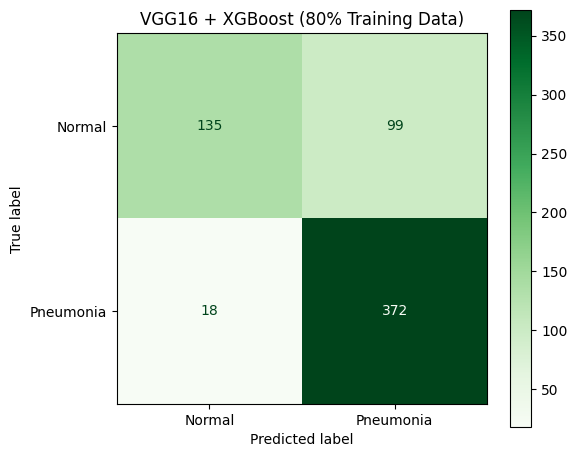

In [ ]:
#vgg16+xgboost
train_acc_list = []
test_acc_list = []
f1_list = []
sensitivity_list = []
specificity_list = []
labels = []

for train_size in train_sizes:

    print("\n======================================")
    print(f"TRAINING DATA USED : {int(train_size*100)}%")
    print("TESTING DATA USED  : 100% Official Test Set")
    print("======================================")

    #SUBSET OF TRAINING DATA
    xtrain, _, ytrain, _ = train_test_split(
        X_train_feats,
        Y_train,
        train_size=train_size,
        random_state=42,
        stratify=Y_train
    )

    print("Training Samples :", xtrain.shape[0])
    print("Testing Samples  :", X_test_feats.shape[0])

    # XGBOOST MODEL
    xgb = XGBClassifier(

        n_estimators=80,
        max_depth=3,
        learning_rate=0.05,
        subsample=0.8,
        colsample_bytree=0.8,
        scale_pos_weight=np.sum(Y_train==0)/np.sum(Y_train==1),
        tree_method='hist',
        reg_lambda=5,
        eval_metric='logloss',
        random_state=42,
        n_jobs=-1,
        verbosity=0
    )

    print("\nTraining VGG16 + XGBoost Model...")

    xgb.fit(
        xtrain,
        ytrain
    )

    print("Training Completed")

    # PREDICTIONS
    train_pred = xgb.predict(xtrain)
    test_pred = xgb.predict(X_test_feats)

    # METRICS
    train_acc = accuracy_score(
        ytrain,
        train_pred
    )

    test_acc = accuracy_score(
        Y_test,
        test_pred
    )

    f1 = f1_score(
        Y_test,
        test_pred,
        average='weighted'
    )

    cm = confusion_matrix(
        Y_test,
        test_pred
    )

    sensitivity = (
        cm[1,1] /
        (cm[1,1] + cm[1,0])
    )

    specificity = (
        cm[0,0] /
        (cm[0,0] + cm[0,1])
    )

    print("Training Accuracy :", train_acc)
    print("Testing Accuracy  :", test_acc)
    print("F1 Score          :", f1)
    print("Sensitivity       :", sensitivity)
    print("Specificity       :", specificity)

    # STORE RESULTS
    train_acc_list.append(train_acc)
    test_acc_list.append(test_acc)
    f1_list.append(f1)
    sensitivity_list.append(sensitivity)
    specificity_list.append(specificity)
    labels.append(
        f"{int(train_size*100)}%"
    )

    # CLASSIFICATION REPORT
    print("\nClassification Report:\n")

    print(
        classification_report(
            Y_test,
            test_pred,
            target_names=list(dec.values())
        )
    )

    # CONFUSION MATRIX
    fig, ax = plt.subplots(figsize=(6,5))

    disp = ConfusionMatrixDisplay(
        confusion_matrix=cm,
        display_labels=list(dec.values())
    )

    disp.plot(
        ax=ax,
        cmap='Greens',
        colorbar=True
    )

    plt.title(
        f"VGG16 + XGBoost ({int(train_size*100)}% Training Data)"
    )

    plt.tight_layout()

    plt.show()

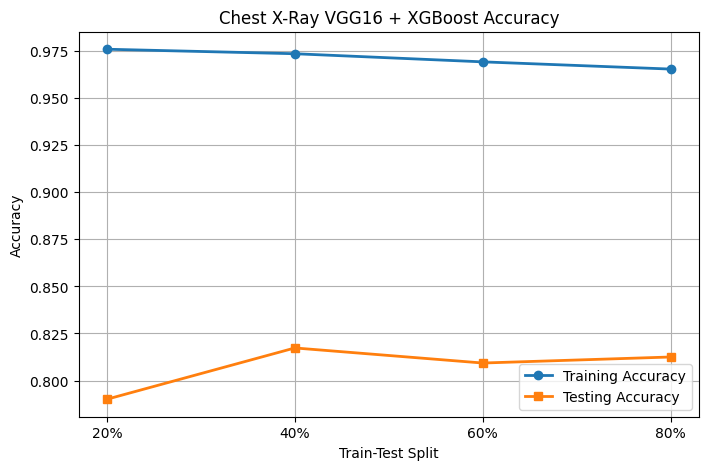

In [ ]:
#accuracy plot
plt.figure(figsize=(8,5))

plt.plot(
    labels,
    train_acc_list,
    marker='o',
    linewidth=2,
    label='Training Accuracy'
)

plt.plot(
    labels,
    test_acc_list,
    marker='s',
    linewidth=2,
    label='Testing Accuracy'
)

plt.xlabel("Train-Test Split")
plt.ylabel("Accuracy")
plt.title("Chest X-Ray VGG16 + XGBoost Accuracy")
plt.legend()
plt.grid(True)
plt.show()

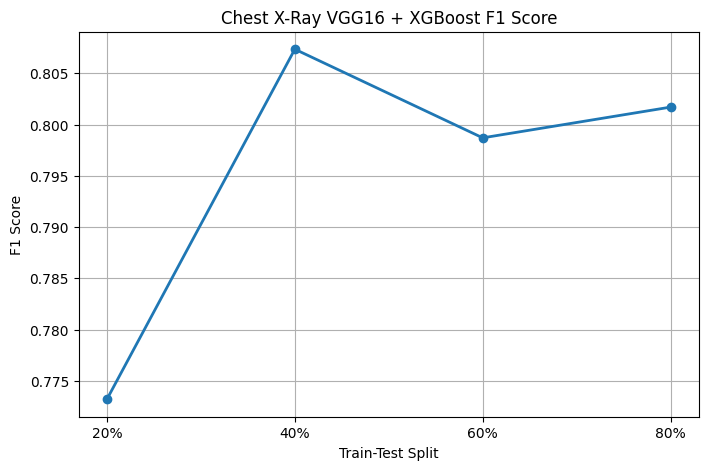

In [ ]:
#f1_plot
plt.figure(figsize=(8,5))
plt.plot(
    labels,
    f1_list,
    marker='o',
    linewidth=2
)

plt.xlabel("Train-Test Split")
plt.ylabel("F1 Score")
plt.title("Chest X-Ray VGG16 + XGBoost F1 Score")
plt.grid(True)
plt.show()

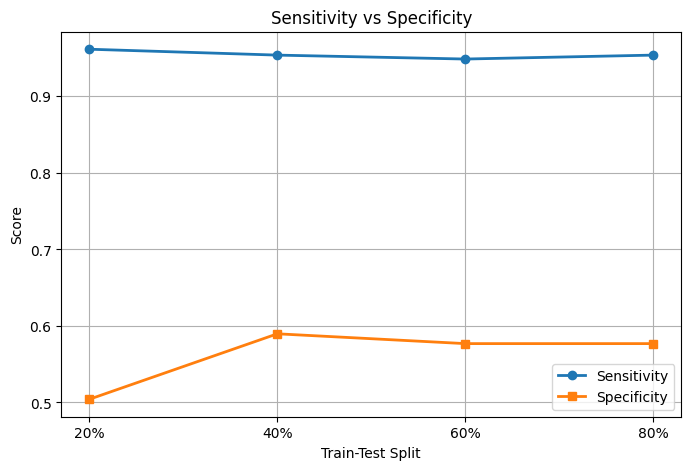

In [ ]:
#sensitvity and specificity
plt.figure(figsize=(8,5))

plt.plot(
    labels,
    sensitivity_list,
    marker='o',
    linewidth=2,
    label='Sensitivity'
)

plt.plot(
    labels,
    specificity_list,
    marker='s',
    linewidth=2,
    label='Specificity'
)

plt.xlabel("Train-Test Split")
plt.ylabel("Score")
plt.title("Sensitivity vs Specificity")
plt.legend()
plt.grid(True)
plt.show()

In [ ]:
#results
results_df = pd.DataFrame({

    'Train-Test Split': labels,
    'Training Accuracy': train_acc_list,
    'Testing Accuracy': test_acc_list,
    'F1 Score': f1_list,
    'Sensitivity': sensitivity_list,
    'Specificity': specificity_list
})

print(results_df)

  Train-Test Split  Training Accuracy  Testing Accuracy  F1 Score  \
0              20%           0.976031          0.790064  0.773210   
1              40%           0.973634          0.817308  0.807343   
2              60%           0.969319          0.809295  0.798700   
3              80%           0.965484          0.812500  0.801698   

   Sensitivity  Specificity  
0     0.961538     0.504274  
1     0.953846     0.589744  
2     0.948718     0.576923  
3     0.953846     0.576923  


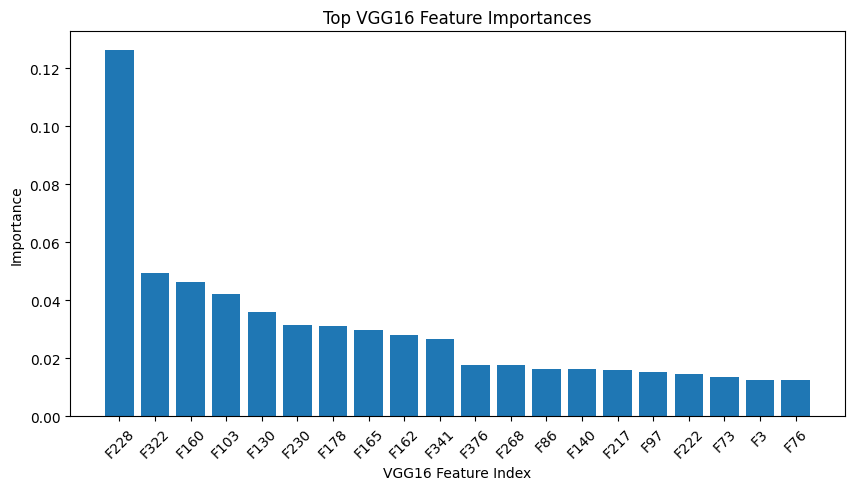

In [ ]:
#feature importance
importances = xgb.feature_importances_

top_idx = np.argsort(
    importances
)[::-1][:20]

plt.figure(figsize=(10,5))

plt.bar(
    range(20),
    importances[top_idx]
)

plt.xticks(
    range(20),
    [f"F{idx+1}" for idx in top_idx],
    rotation=45
)

plt.xlabel("VGG16 Feature Index")
plt.ylabel("Importance")
plt.title("Top VGG16 Feature Importances")
plt.show()

In [ ]:
#sample predictions
test_path = os.path.join(
    path,
    "chest_xray",
    "test"
)
def display_samples_vgg(folder, title, num_samples=9):

    valid_ext = (
        '.jpg',
        '.jpeg',
        '.png'
    )

    files = [
        f for f in os.listdir(folder)
        if f.lower().endswith(valid_ext)
    ]

    files = files[:num_samples]

    if len(files) == 0:
        return

    cols = min(3, len(files))
    rows = (len(files) + cols - 1) // cols
    plt.figure(figsize=(12,4*rows))

    for i, filename in enumerate(files, 1):

        img_path = os.path.join(
            folder,
            filename
        )

        img = cv2.imread(img_path)

        if img is None:
            continue

        img = cv2.cvtColor(
            img,
            cv2.COLOR_BGR2RGB
        )

        img = cv2.resize(
            img,
            (IMG_SIZE, IMG_SIZE)
        )

        img_input = preprocess_input(
            np.expand_dims(
                img.astype(np.float32),
                axis=0
            )
        )

        feat = extractor.predict(
            img_input,
            verbose=0
        )

        pred = xgb.predict(feat)[0]
        plt.subplot(rows, cols, i)
        plt.imshow(img)
        plt.title(
            dec[pred],
            color='green' if pred == 0 else 'red'
        )

        plt.axis('off')

    plt.suptitle(title)
    plt.tight_layout()
    plt.show()

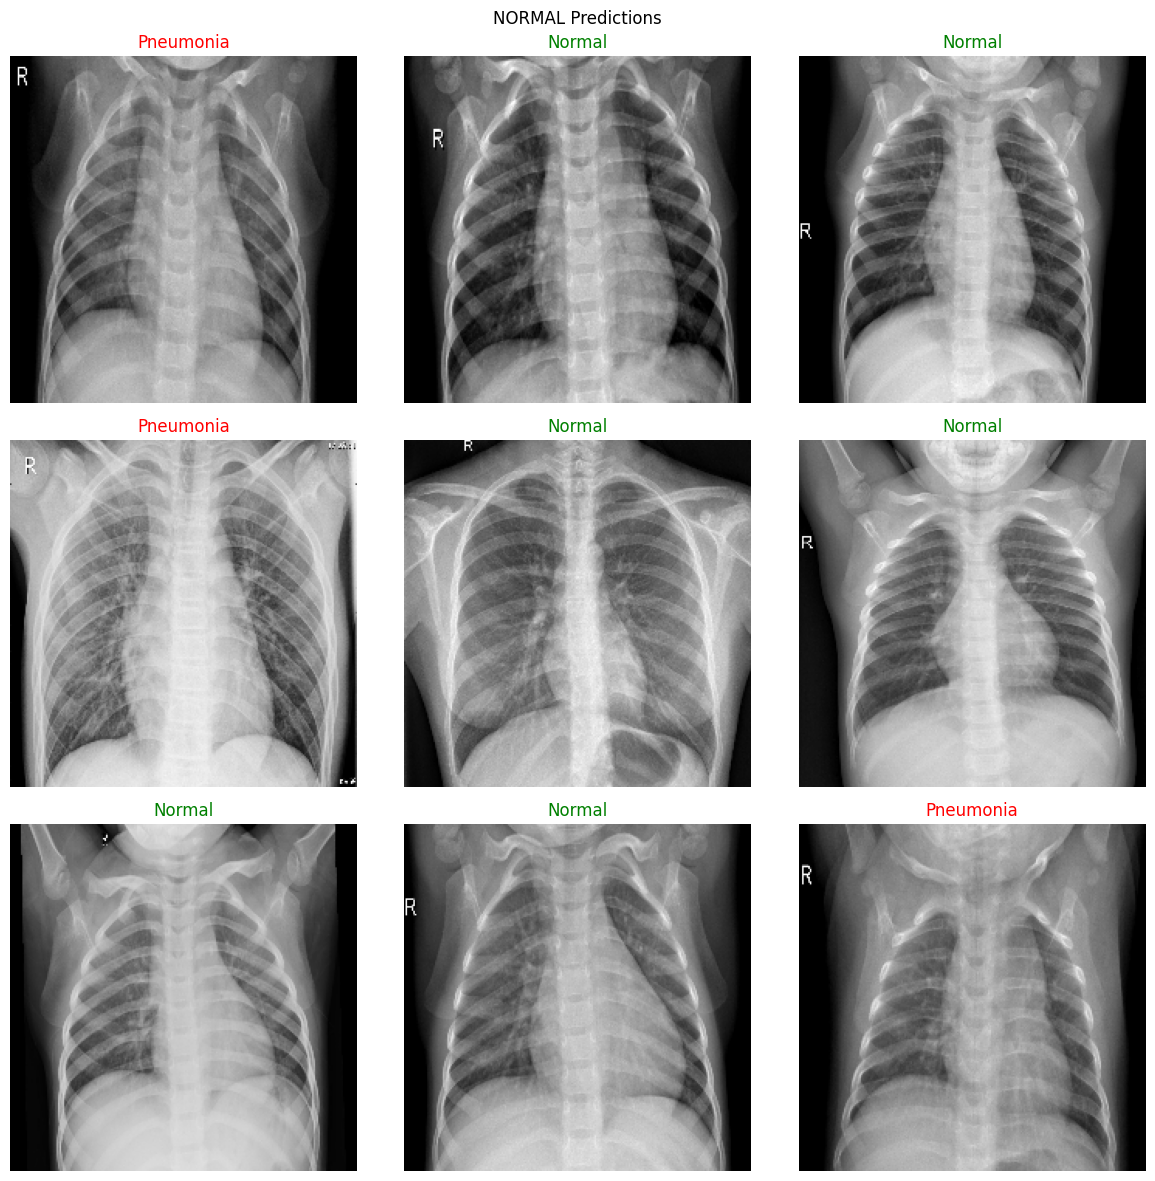

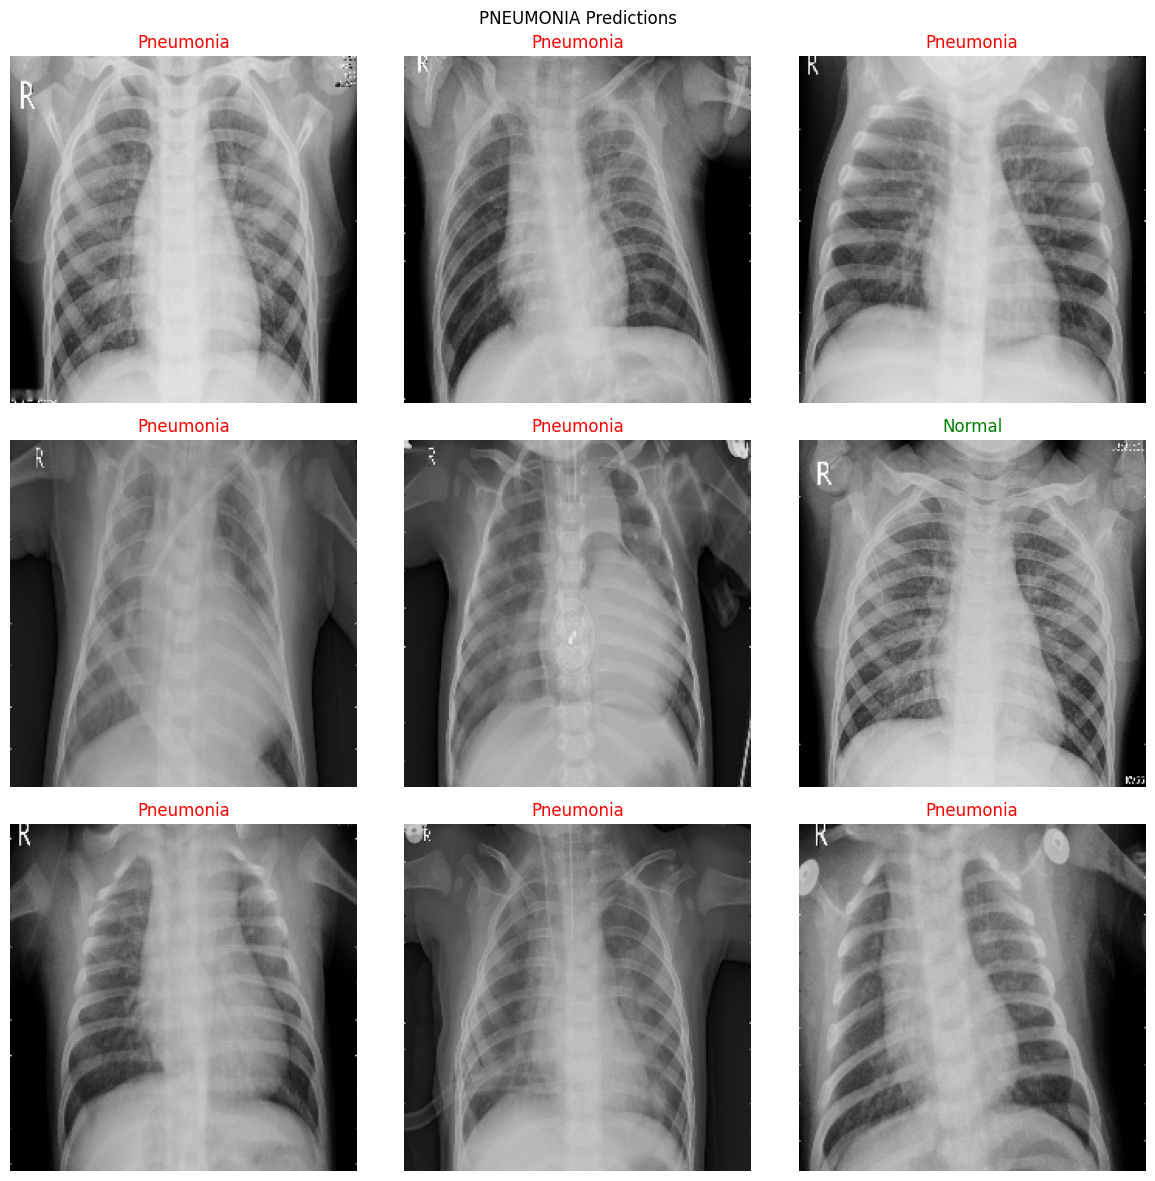

In [ ]:
#display sample predictions

for cls_folder in classes.keys():

    folder_path = os.path.join(
        test_path,
        cls_folder
    )

    if os.path.isdir(folder_path):

        display_samples_vgg(
            folder_path,
            f"{cls_folder} Predictions"
        )

In [ ]:
#dataset distribution
plt.figure(figsize=(6,5))

for label, color in zip(
    [0,1],
    ['skyblue', 'orange']
):

    plt.bar(
        dec[label],
        int(np.sum(Y_train == label)),
        color=color,
        edgecolor='black'
    )

plt.xlabel("Class")
plt.ylabel("Count")
plt.title("Chest X-Ray Dataset Distribution")
plt.show()